# 🏎️ Módulo 1 — Comparador de Voltas

Este notebook compara a telemetria de dois pilotos de F1 numa mesma 
sessão, usando dados reais via FastF1. Permite identificar onde um 
piloto ganha ou perde tempo ao longo da volta.

**Exemplo usado:** GP da Espanha 2025, Classificação — Piastri vs Norris

In [1]:
import sys
import os

# Adiciona a pasta raiz do projeto ao caminho de busca do Python
sys.path.append(os.path.abspath('..'))

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

from funcoes_telemetria import (
    comparar_pilotos, encontrar_ponto_na_pista, mapa_velocidade,
    comparar_mapas_velocidade, analisar_stints, obter_dados_corrida,
    comparar_stints, ranking_sessao, calcular_g_longitudinal, calcular_g_lateral,
    diagrama_gg, calcular_energia_frenagem, mapa_energia_frenagem, comparar_energia_frenagem, comparar_setores
    
)

print("Funções importadas com sucesso!")
print("Funções importadas com sucesso!")

Funções importadas com sucesso!
Funções importadas com sucesso!


# visualização do FP3 do GP analisado

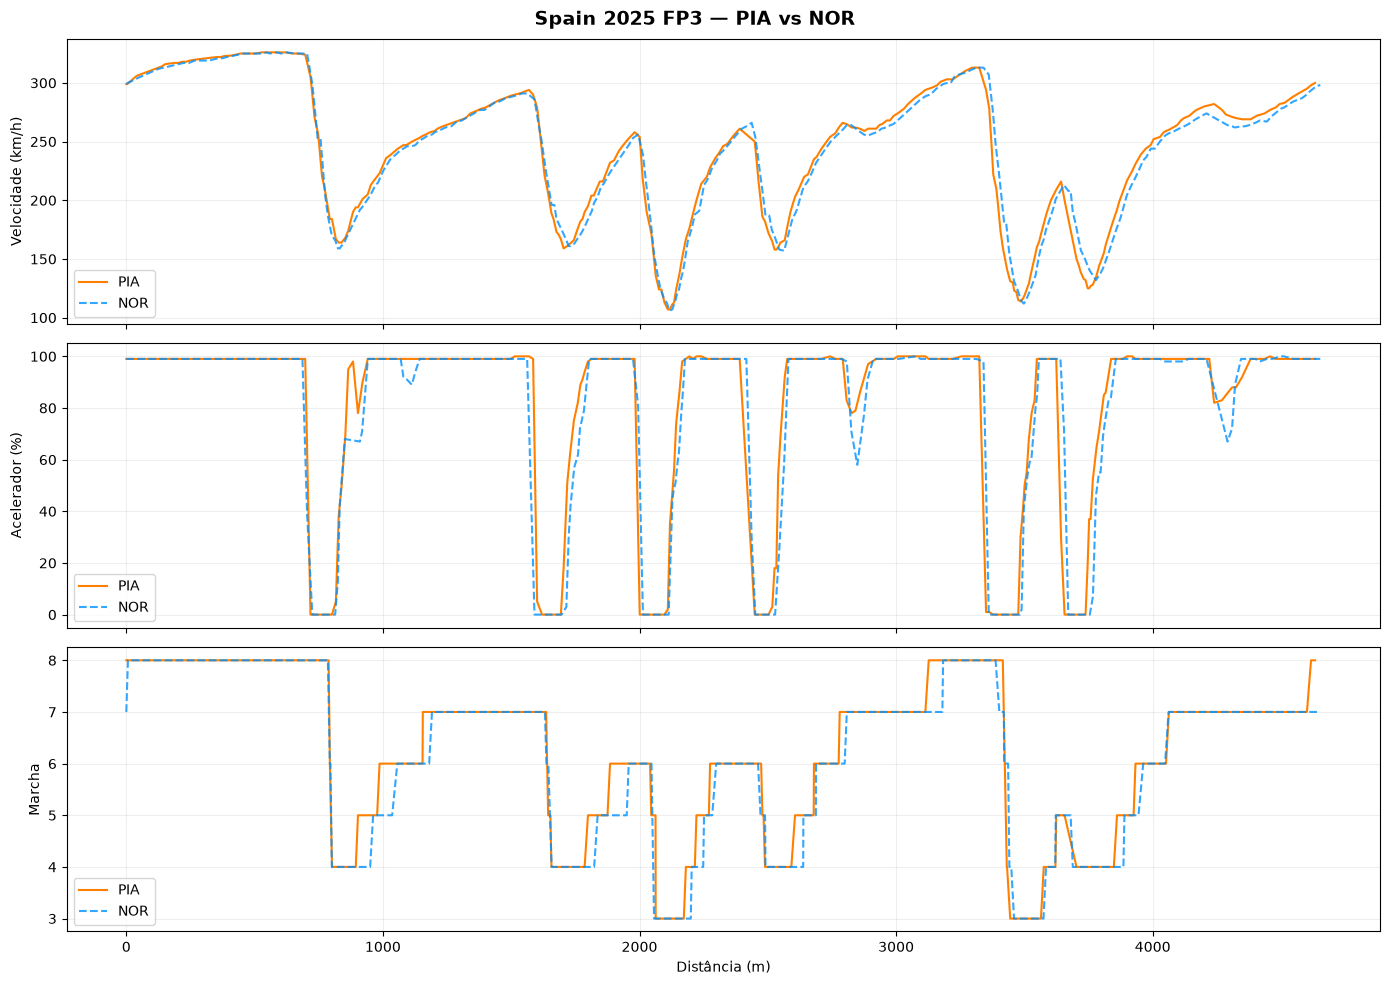

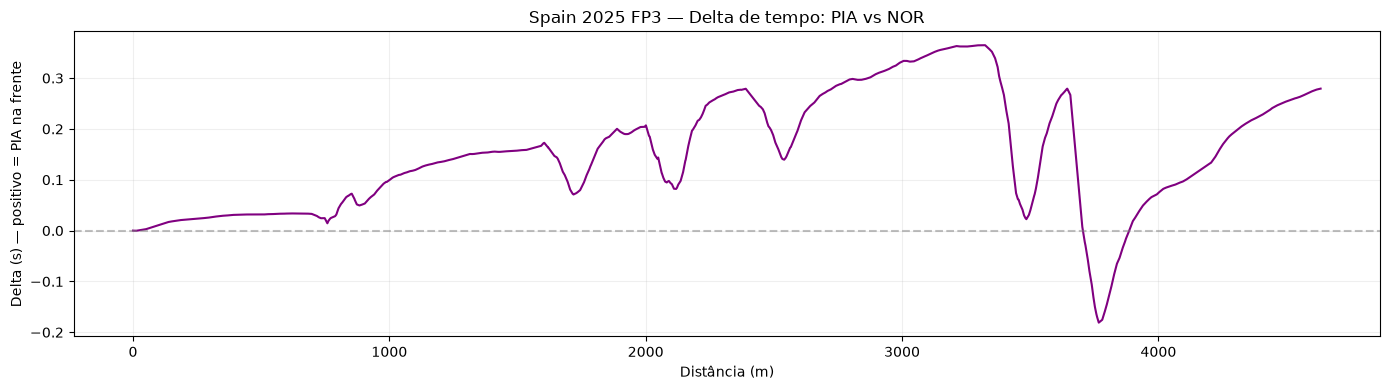

In [2]:
tel_pia, tel_nor, fig1, fig2 = comparar_pilotos(2025, 'Spain', 'FP3', 'PIA', 'NOR')

# Visualização do FP2 do GP analisado

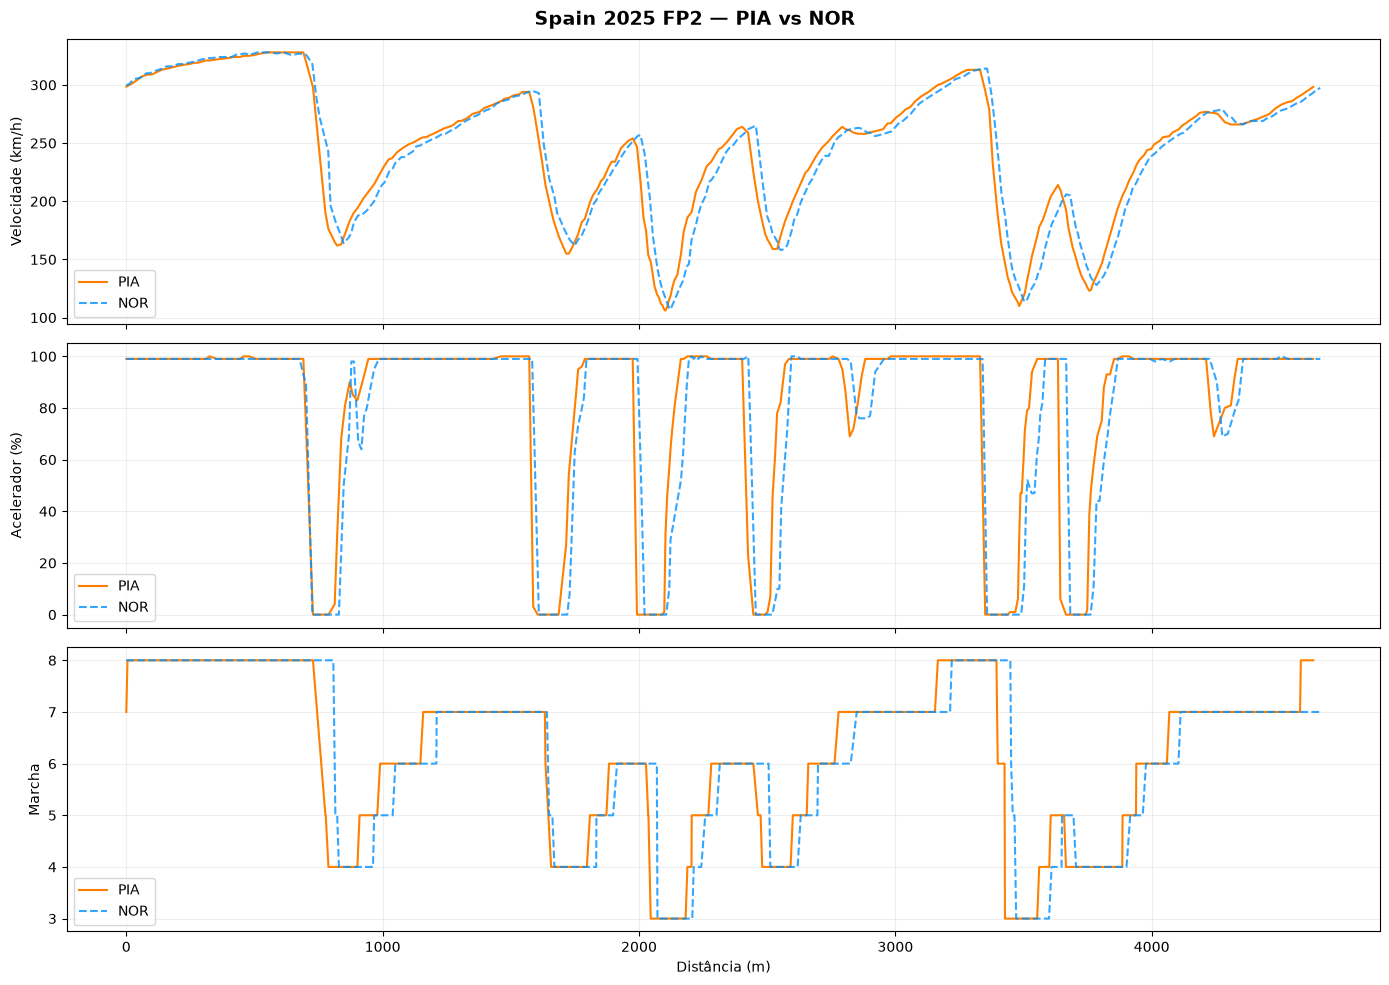

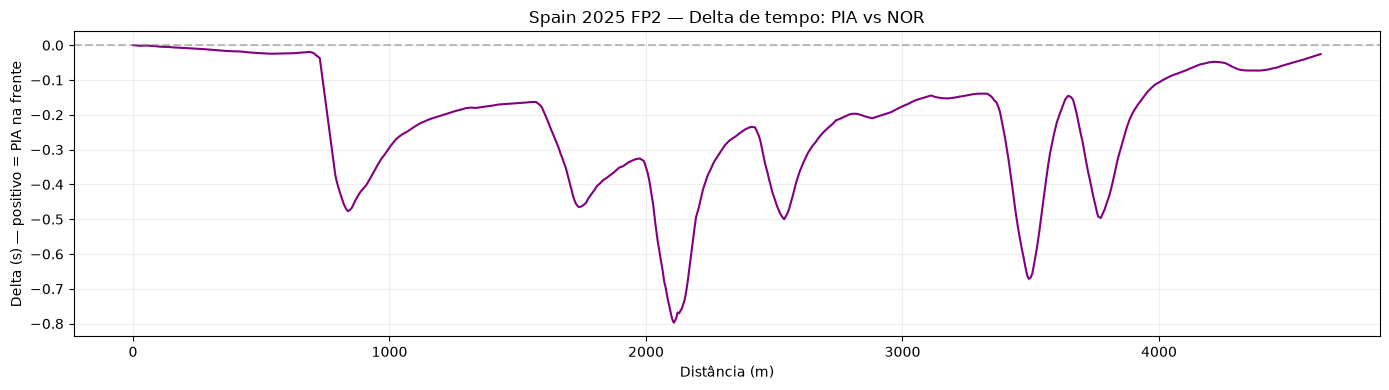

In [3]:
tel_pia, tel_nor, fig1, fig2 = comparar_pilotos(2025, 'Spain', 'FP2', 'PIA', 'NOR')

# visualização do FP1 do GP analisado

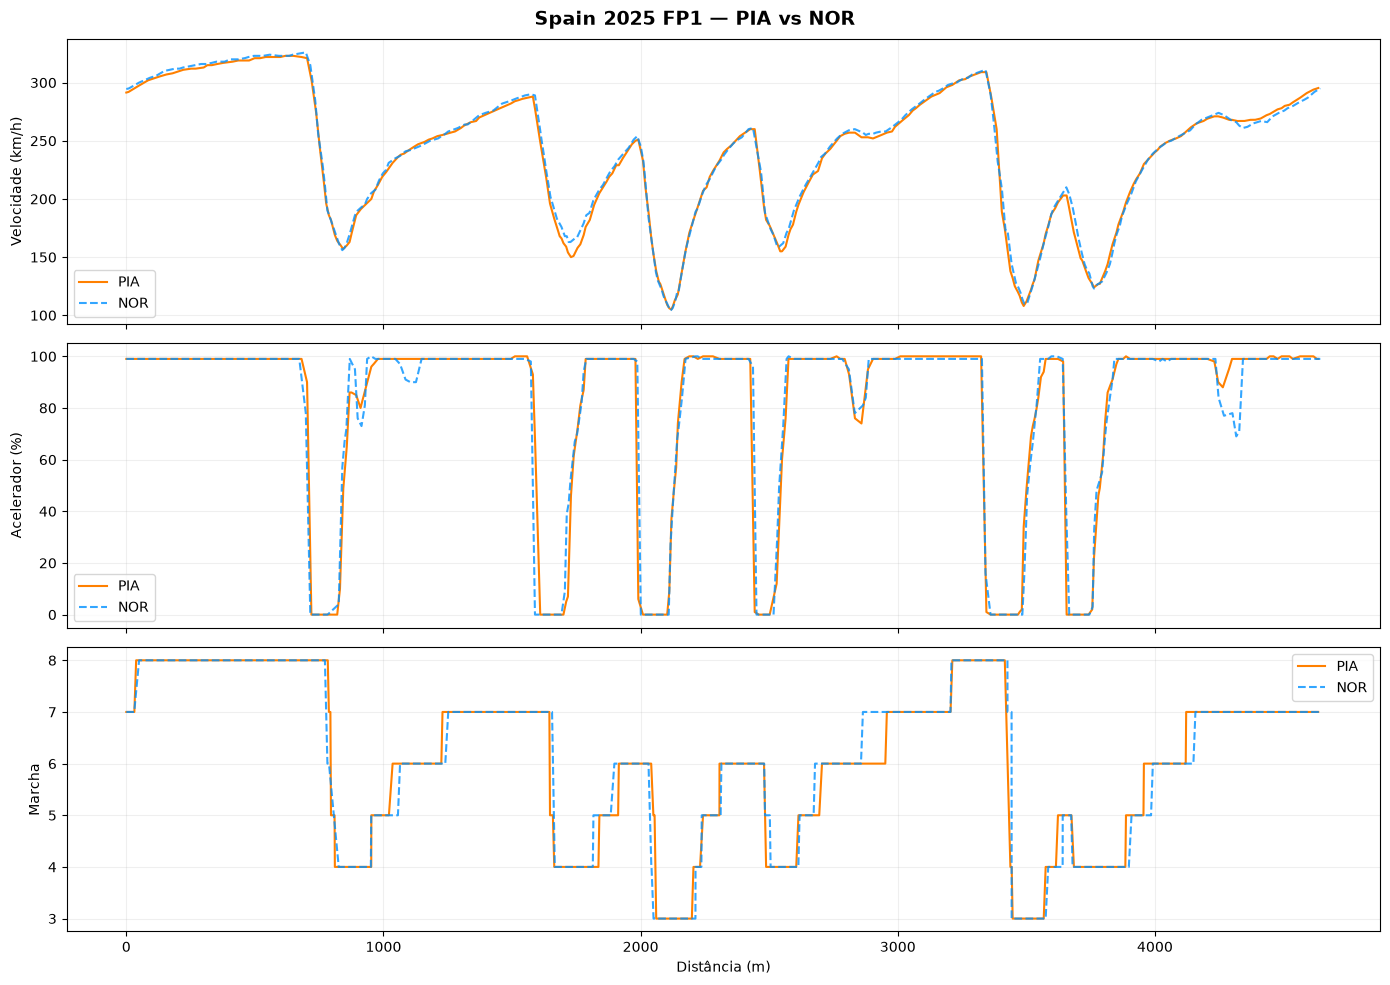

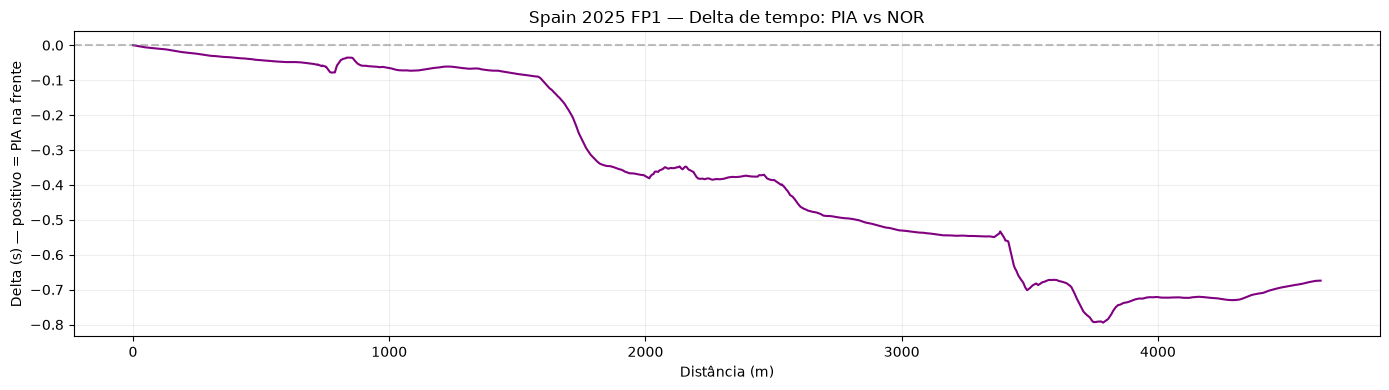

In [4]:
tel_pia, tel_nor, fig1, fig2 = comparar_pilotos(2025, 'Spain', 'FP1', 'PIA', 'NOR')

# visualização do QUALY(melhor volta) do GP analisado

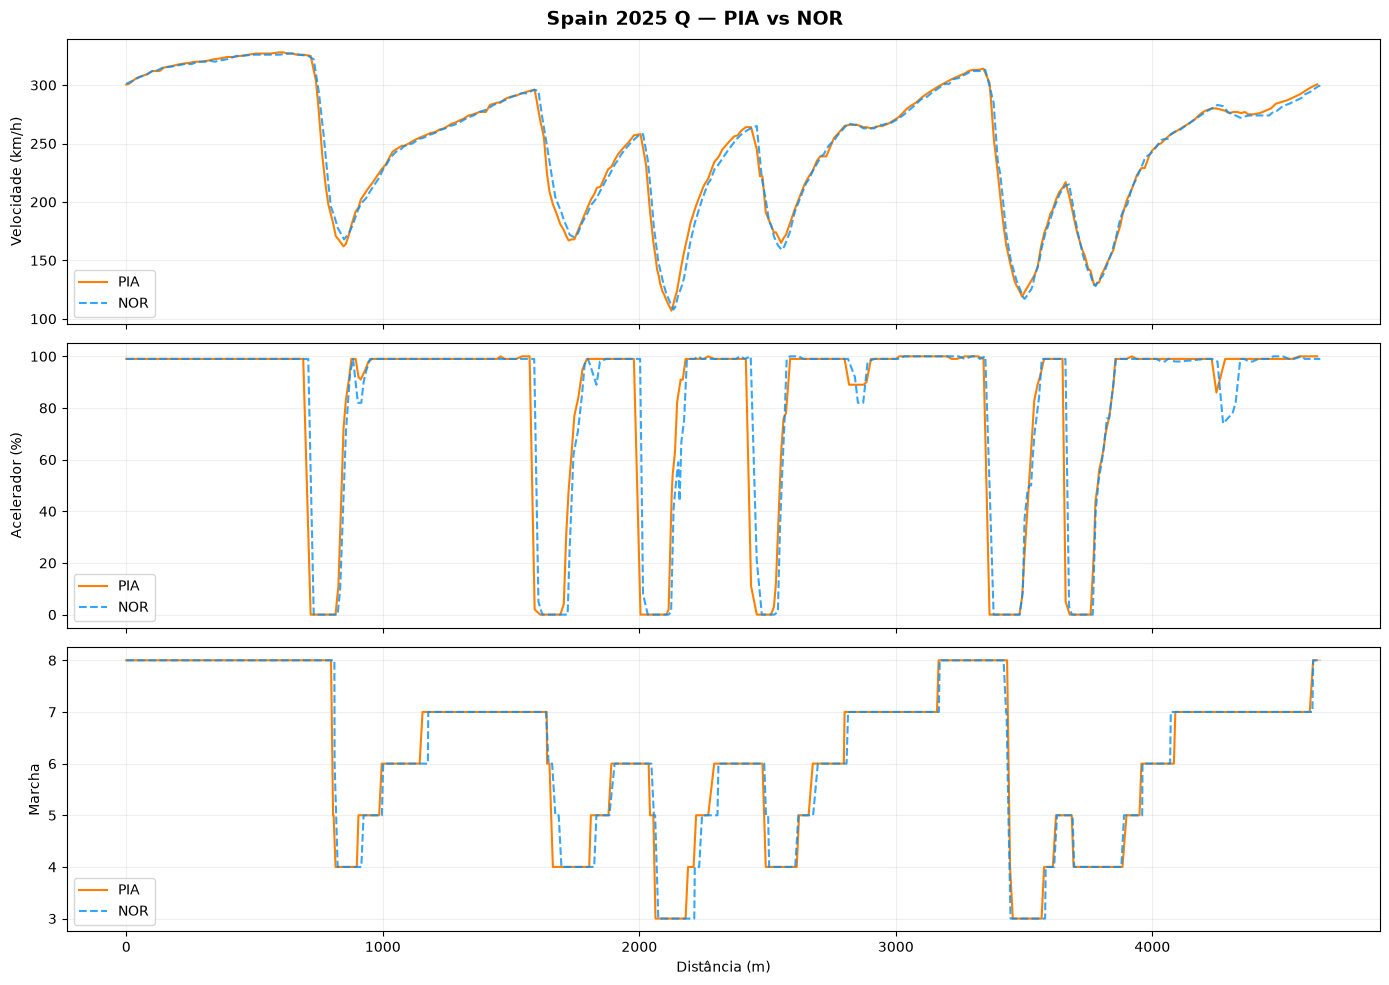

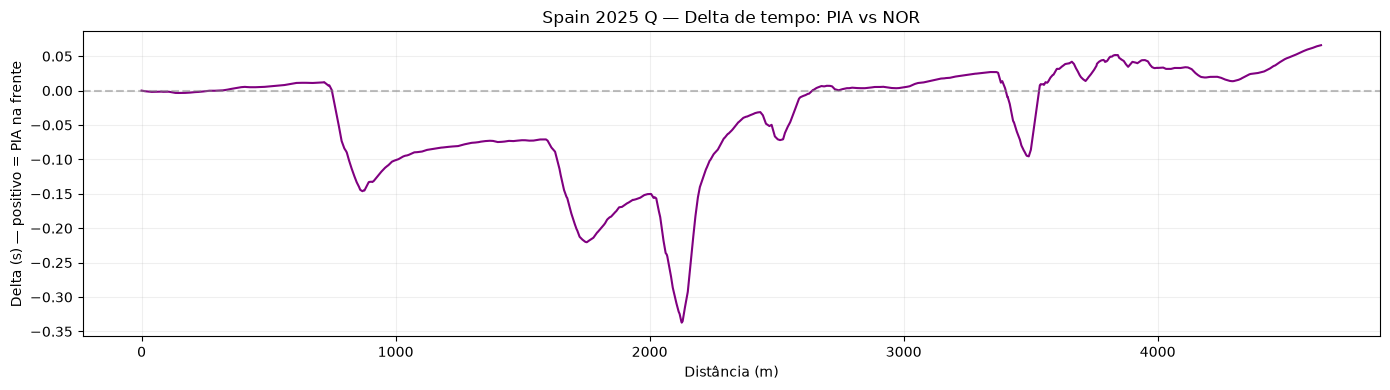

In [5]:
tel_pia, tel_nor, fig1, fig2 = comparar_pilotos(2025, 'Spain', 'Q', 'PIA', 'NOR')

# visualização da corrida(melhor volta) do GP analisado

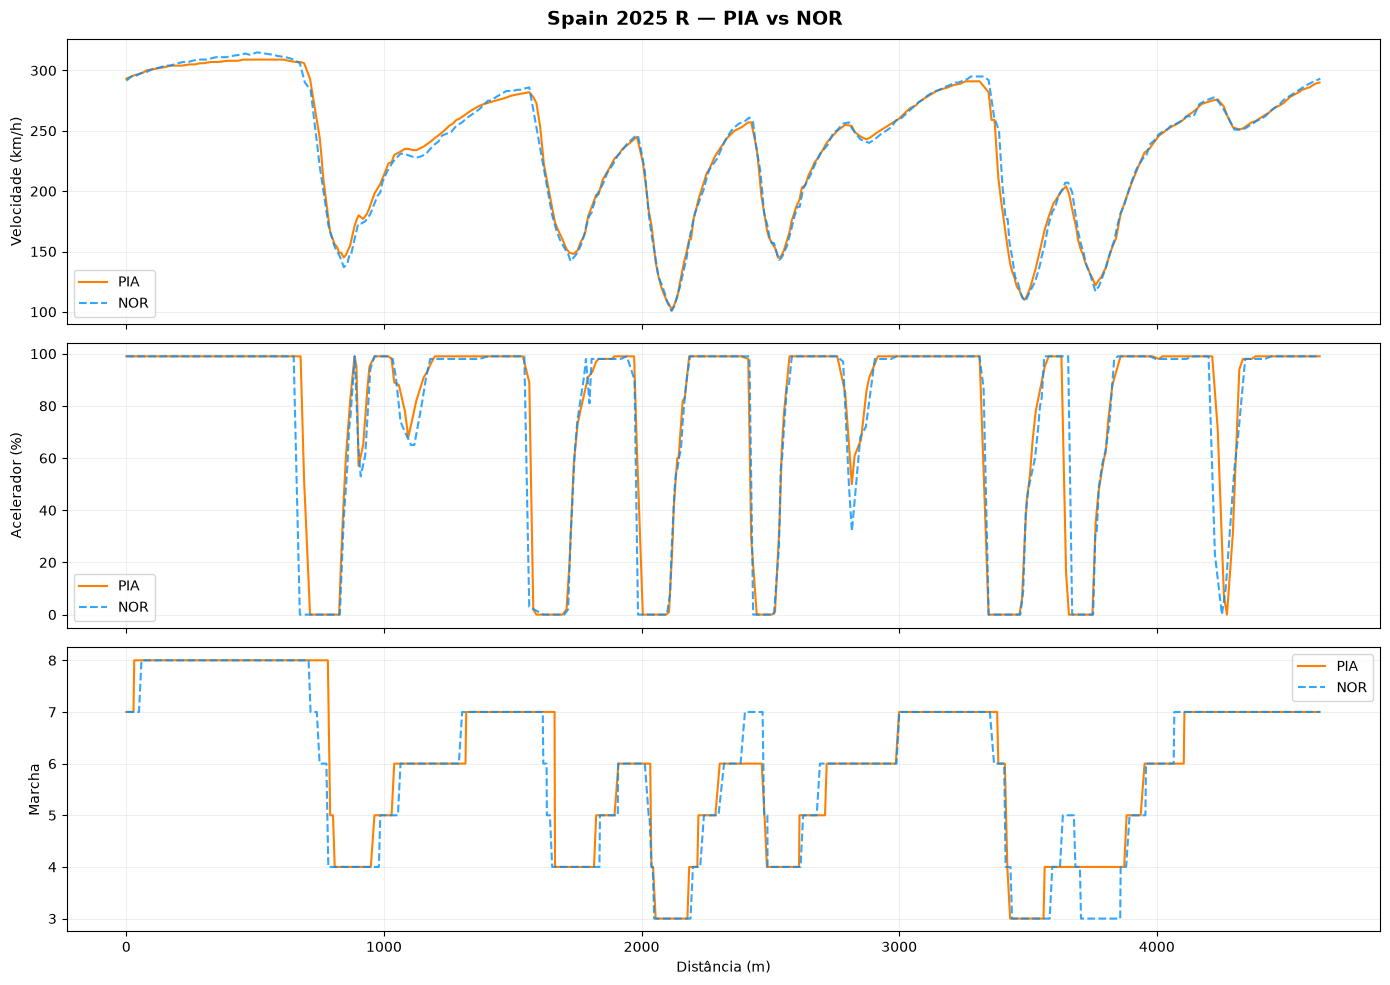

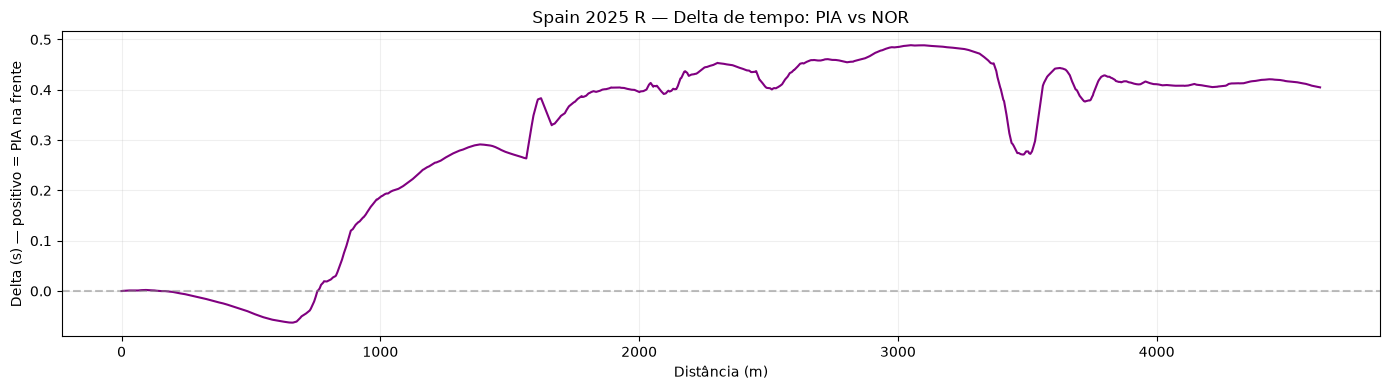

In [6]:
tel_pia, tel_nor, fig1, fig2 = comparar_pilotos(2025, 'Spain', 'R', 'PIA', 'NOR')

# Estudando um ponto interessante com uma grande troca de vantagem

In [7]:
def encontrar_ponto_na_pista(telemetria, distancia_alvo):
    """
    Recebe a telemetria de uma volta e uma distância (em metros),
    e retorna as coordenadas X, Y do ponto mais próximo dessa distância.
    """
    idx = (telemetria['Distance'] - distancia_alvo).abs().idxmin()
    x = telemetria.loc[idx, 'X']
    y = telemetria.loc[idx, 'Y']
    return x, y

In [8]:
x_evento, y_evento = encontrar_ponto_na_pista(tel_pia, 3400)
print(f"Ponto em X={x_evento:.0f}, Y={y_evento:.0f}")

Ponto em X=1165, Y=1751


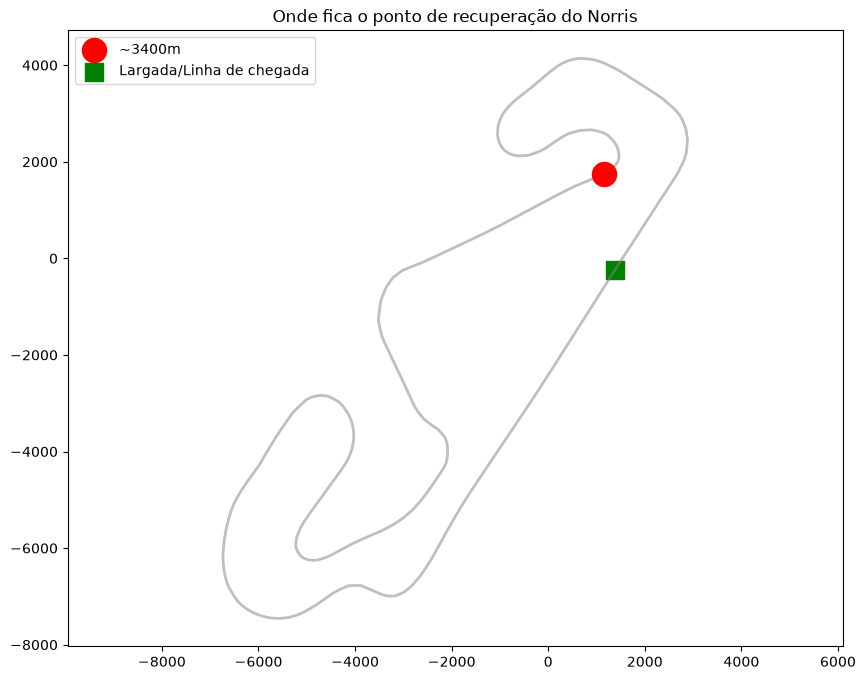

In [9]:
plt.figure(figsize=(10, 8))
plt.plot(tel_pia['X'], tel_pia['Y'], color='gray', linewidth=2, alpha=0.5)
plt.scatter(x_evento, y_evento, color='red', s=300, zorder=5, label='~3400m')
plt.scatter(tel_pia['X'].iloc[0], tel_pia['Y'].iloc[0], color='green', s=150, marker='s', label='Largada/Linha de chegada')

plt.title('Onde fica o ponto de recuperação do Norris')
plt.legend()
plt.axis('equal')
plt.show()

# A partir daqui estamos "automatizando" essa comparação com o delta de tempo. Comparando com mais pilotos agora

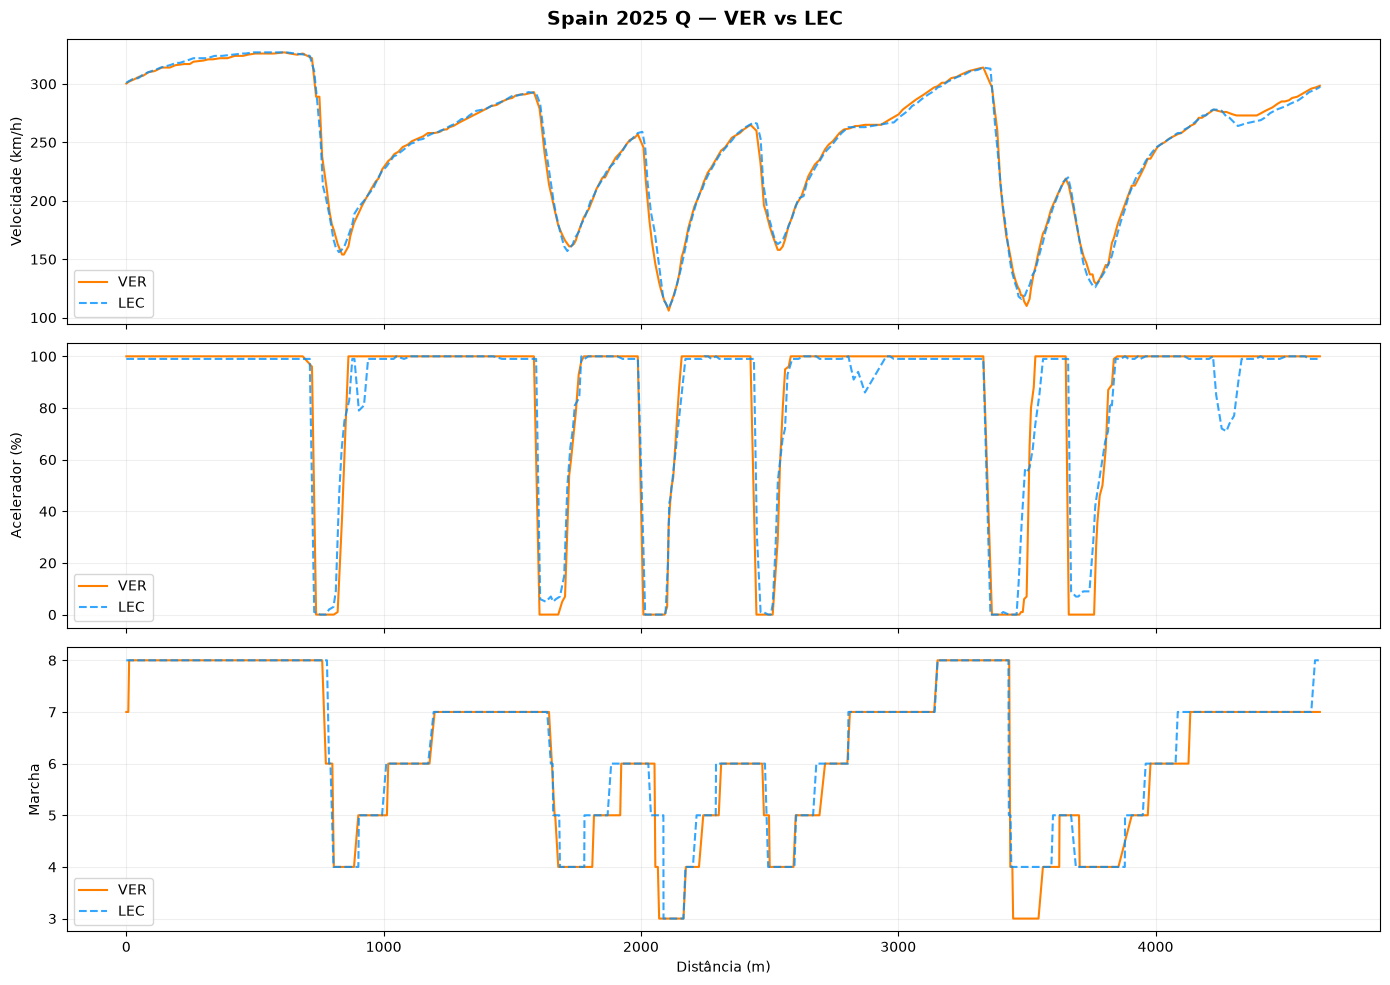

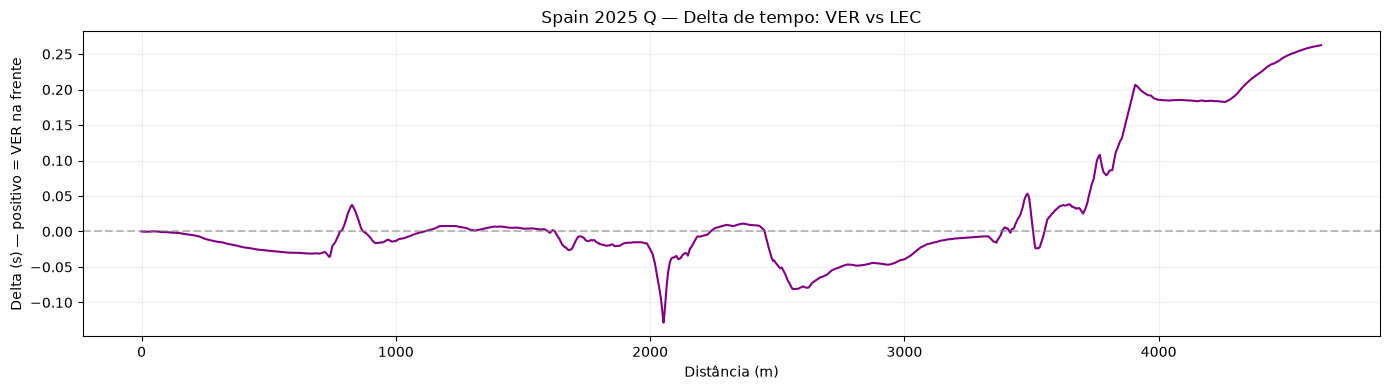

In [10]:
tel_ver, tel_lec, fig1, fig2 = comparar_pilotos(2025, 'Spain', 'Q', 'VER', 'LEC')

# Abaixo um gráfico que mostra a distribuição da velocidade do piloto em toda a pista. Mostrando os trechos com suas velocidades, é bem intuitivo e prático

In [11]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def mapa_velocidade(telemetria, titulo='Mapa de velocidade'):
    """
    Plota o traçado da pista colorido pela velocidade em cada ponto.
    """
    x = telemetria['X'].values
    y = telemetria['Y'].values
    speed = telemetria['Speed'].values
    
    # Cria pares de pontos consecutivos (segmentos de linha)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    norm = Normalize(vmin=speed.min(), vmax=speed.max())
    lc = LineCollection(segments, cmap='plasma', norm=norm)
    lc.set_array(speed)
    lc.set_linewidth(4)
    
    line = ax.add_collection(lc)
    ax.set_xlim(x.min() - 200, x.max() + 200)
    ax.set_ylim(y.min() - 200, y.max() + 200)
    ax.axis('equal')
    ax.axis('off')  # remove os eixos, fica mais limpo visualmente
    ax.set_title(titulo)
    
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('Velocidade (km/h)')
    
    plt.show()

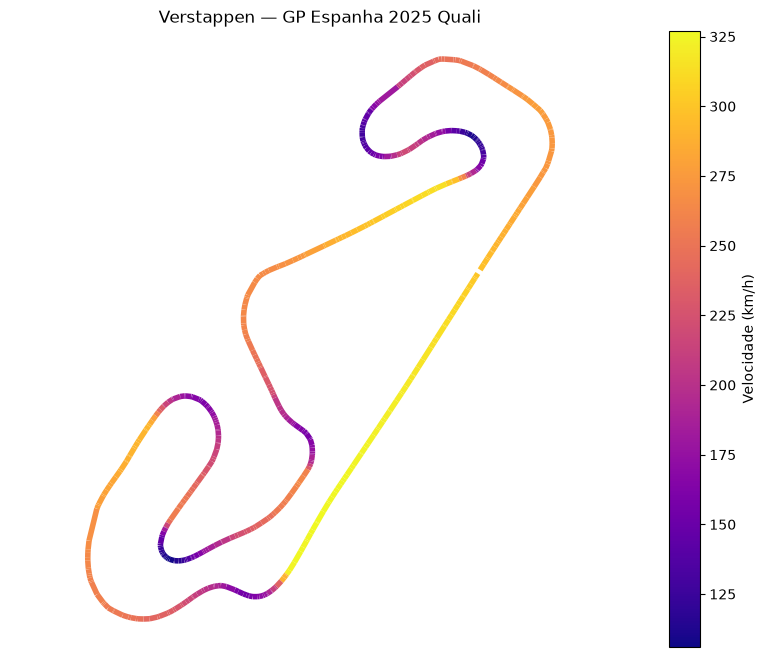

In [12]:
fig = mapa_velocidade(tel_ver, titulo='Verstappen — GP Espanha 2025 Quali')

# Agora comparando...

In [13]:
def comparar_mapas_velocidade(tel1, tel2, nome1, nome2, titulo_geral=''):
    """
    Plota dois mapas de velocidade lado a lado, na mesma escala de cor,
    pra comparação direta entre dois pilotos.
    """
    # Pega o min/max de velocidade considerando os DOIS pilotos juntos
    # (importante pra escala de cor ser igual nos dois gráficos)
    speed_min = min(tel1['Speed'].min(), tel2['Speed'].min())
    speed_max = max(tel1['Speed'].max(), tel2['Speed'].max())
    norm = Normalize(vmin=speed_min, vmax=speed_max)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for ax, tel, nome in zip(axes, [tel1, tel2], [nome1, nome2]):
        x = tel['X'].values
        y = tel['Y'].values
        speed = tel['Speed'].values
        
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        lc = LineCollection(segments, cmap='plasma', norm=norm)
        lc.set_array(speed)
        lc.set_linewidth(4)
        
        ax.add_collection(lc)
        ax.set_xlim(x.min() - 200, x.max() + 200)
        ax.set_ylim(y.min() - 200, y.max() + 200)
        ax.axis('equal')
        ax.axis('off')
        ax.set_title(nome)
    
    fig.suptitle(titulo_geral, fontsize=14, fontweight='bold')
    
    # Uma única barra de cor compartilhada pelos dois gráficos
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='plasma'), ax=axes, fraction=0.03)
    cbar.set_label('Velocidade (km/h)')
    
    plt.show()

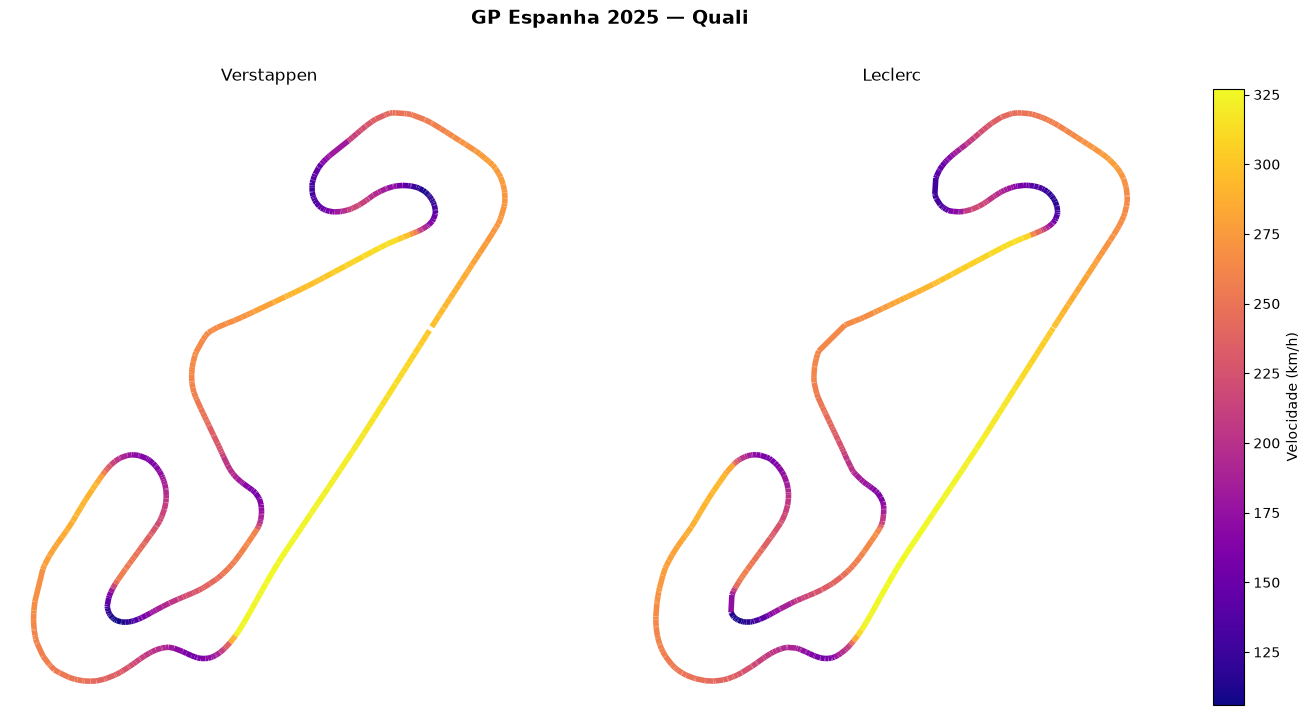

In [14]:
fig = comparar_mapas_velocidade(tel_ver, tel_lec, 'Verstappen', 'Leclerc', 
                            titulo_geral='GP Espanha 2025 — Quali')

# Analisaremos agora os instints do GP usado em todo o teste

In [15]:
session_corrida = fastf1.get_session(2025, 'Spain', 'R')
session_corrida.load()

voltas_pia = session_corrida.laps.pick_driver('PIA')

# Mostra só a primeira e última volta de cada stint, pra ver a transição
voltas_pia.groupby('Stint').agg(
    primeira_volta=('LapNumber', 'min'),
    ultima_volta=('LapNumber', 'max'),
    composto=('Compound', 'first')
)

,primeira_volta,ultima_volta,composto
Stint,,,
1.0,1.0,22.0,SOFT
2.0,23.0,49.0,MEDIUM
3.0,50.0,55.0,SOFT
4.0,56.0,66.0,SOFT


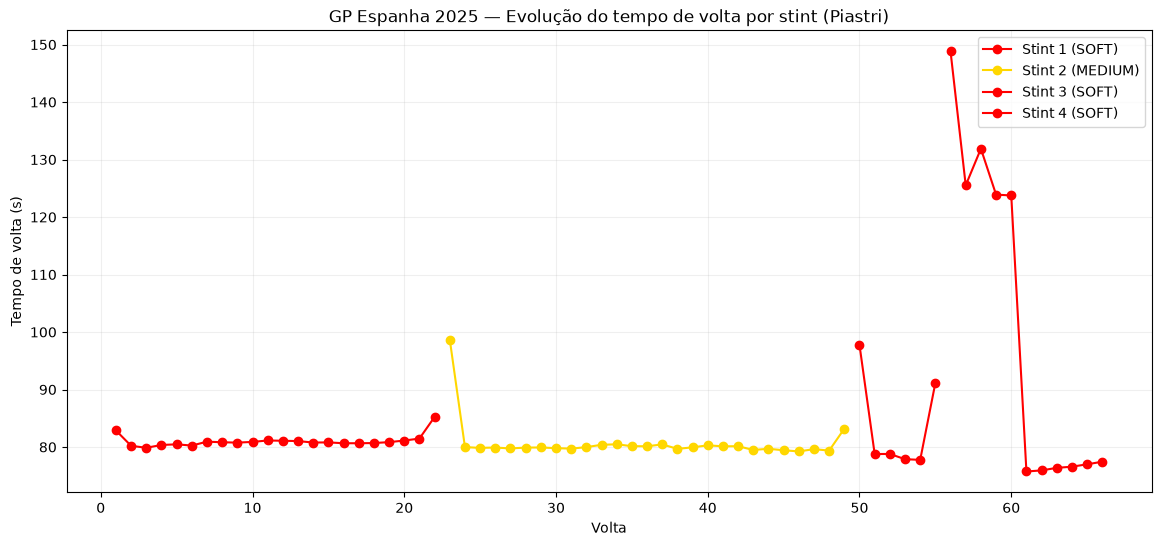

In [16]:
cores_composto = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray', 'INTERMEDIATE': 'green', 'WET': 'blue'}

plt.figure(figsize=(14, 6))

for stint_num in voltas_pia['Stint'].unique():
    stint_data = voltas_pia[voltas_pia['Stint'] == stint_num]
    composto = stint_data['Compound'].iloc[0]
    cor = cores_composto.get(composto, 'black')
    
    plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(), 
              marker='o', color=cor, label=f'Stint {int(stint_num)} ({composto})')

plt.xlabel('Volta')
plt.ylabel('Tempo de volta (s)')
plt.title('GP Espanha 2025 — Evolução do tempo de volta por stint (Piastri)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Automatizando novamente...

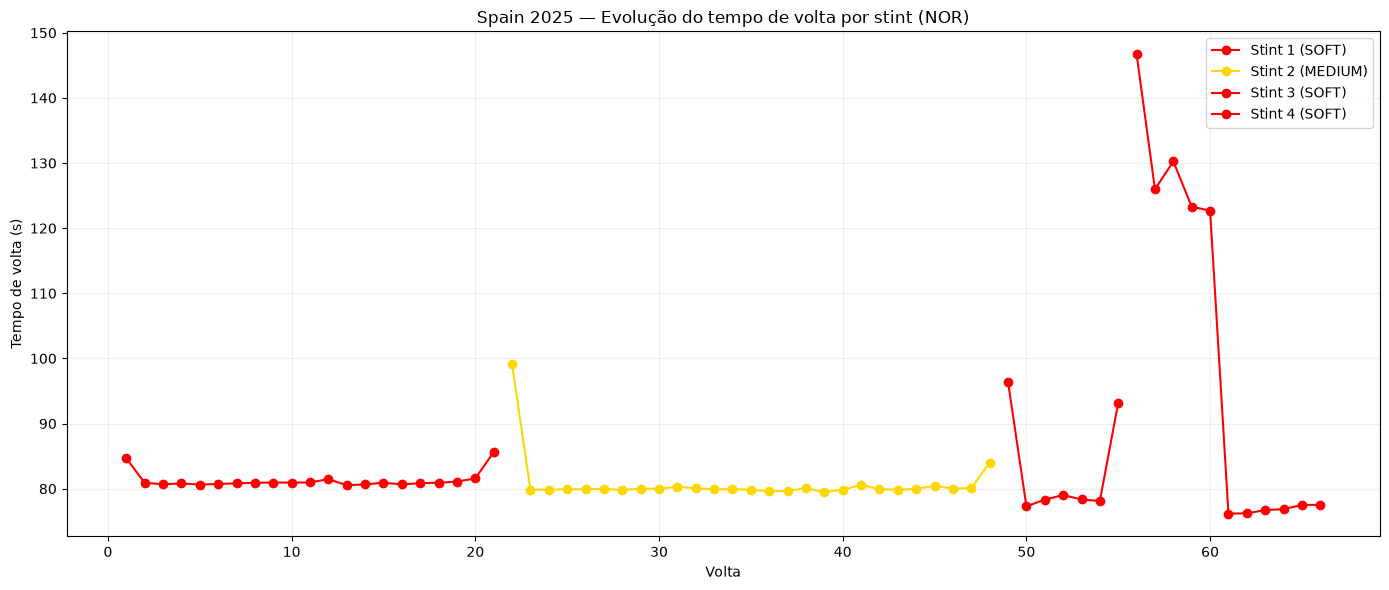

In [17]:
voltas_nor, fig = analisar_stints(2025, 'Spain', 'NOR')

In [18]:
import inspect
print(inspect.getsource(analisar_stints))

def analisar_stints(ano, gp, piloto):
    """
    Plota a evolução do tempo de volta por stint numa corrida,
    colorido por composto de pneu usado.
    Retorna (voltas, fig).
    """
    session = fastf1.get_session(ano, gp, 'R')
    session.load()

    voltas = session.laps.pick_driver(piloto)

    cores_composto = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray',
                      'INTERMEDIATE': 'green', 'WET': 'blue'}

    fig, ax = plt.subplots(figsize=(14, 6))

    for stint_num in voltas['Stint'].unique():
        stint_data = voltas[voltas['Stint'] == stint_num]
        composto = stint_data['Compound'].iloc[0]
        cor = cores_composto.get(composto, 'black')

        ax.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(),
                marker='o', color=cor, label=f'Stint {int(stint_num)} ({composto})')

    ax.set_xlabel('Volta')
    ax.set_ylabel('Tempo de volta (s)')
    ax.set_title(f'{gp} {ano} — Evolução do tempo de volta por stint ({piloto}

# Iremos comparar os instints de 2 pilotos agora

In [19]:
def obter_dados_corrida(ano, gp, piloto):
    """
    Carrega a corrida e retorna as voltas de um piloto específico,
    sem plotar nada.
    """
    session = fastf1.get_session(ano, gp, 'R')
    session.load()
    voltas = session.laps.pick_driver(piloto)
    return voltas

In [20]:
def comparar_stints(voltas1, voltas2, nome1, nome2, titulo=''):
    """
    Sobrepõe a evolução do tempo de volta de dois pilotos no mesmo gráfico,
    diferenciando por estilo de linha e colorindo por composto.
    """
    cores_composto = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray', 
                       'INTERMEDIATE': 'green', 'WET': 'blue'}
    
    plt.figure(figsize=(14, 6))
    
    # Piloto 1 — linha sólida
    for stint_num in voltas1['Stint'].unique():
        stint_data = voltas1[voltas1['Stint'] == stint_num]
        composto = stint_data['Compound'].iloc[0]
        cor = cores_composto.get(composto, 'black')
        plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(),
                  marker='o', color=cor, linestyle='-', alpha=0.9,
                  label=f'{nome1} - Stint {int(stint_num)} ({composto})')
    
    # Piloto 2 — linha tracejada
    for stint_num in voltas2['Stint'].unique():
        stint_data = voltas2[voltas2['Stint'] == stint_num]
        composto = stint_data['Compound'].iloc[0]
        cor = cores_composto.get(composto, 'black')
        plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(),
                  marker='^', color=cor, linestyle='--', alpha=0.6,
                  label=f'{nome2} - Stint {int(stint_num)} ({composto})')
    
    plt.xlabel('Volta')
    plt.ylabel('Tempo de volta (s)')
    plt.title(titulo)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.2)
    plt.show()

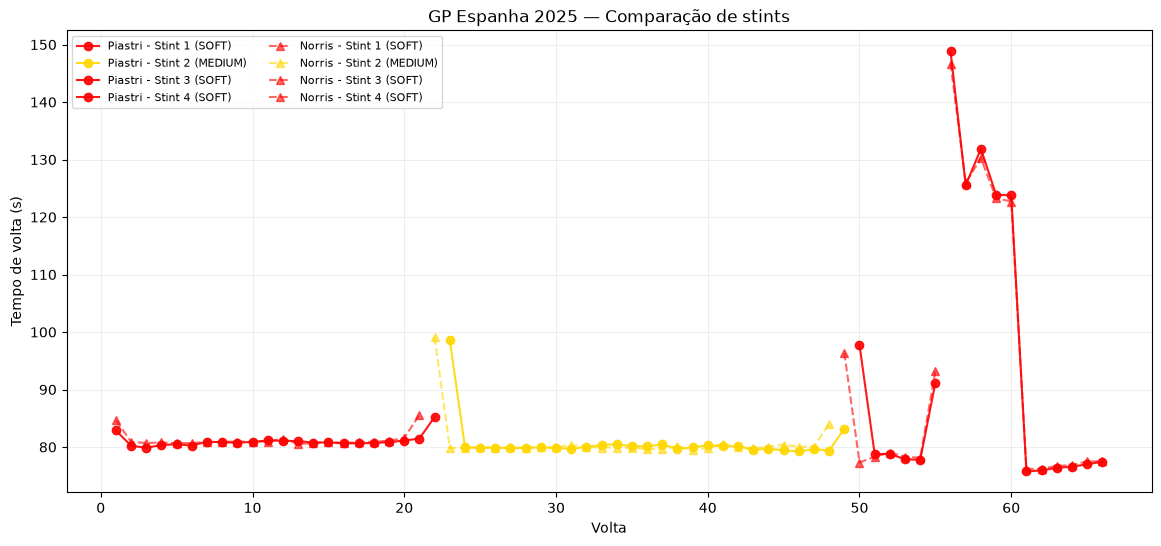

In [21]:
voltas_pia2 = obter_dados_corrida(2025, 'Spain', 'PIA')
voltas_nor2 = obter_dados_corrida(2025, 'Spain', 'NOR')

fig = comparar_stints(voltas_pia2, voltas_nor2, 'Piastri', 'Norris',
                 titulo='GP Espanha 2025 — Comparação de stints')

# Subiremos o nível do modulo agora, iremos analisar a melhor volta de todos os pilotos do grid

# Mais uma vez, automatizando...

teste com o fp2 desse gp

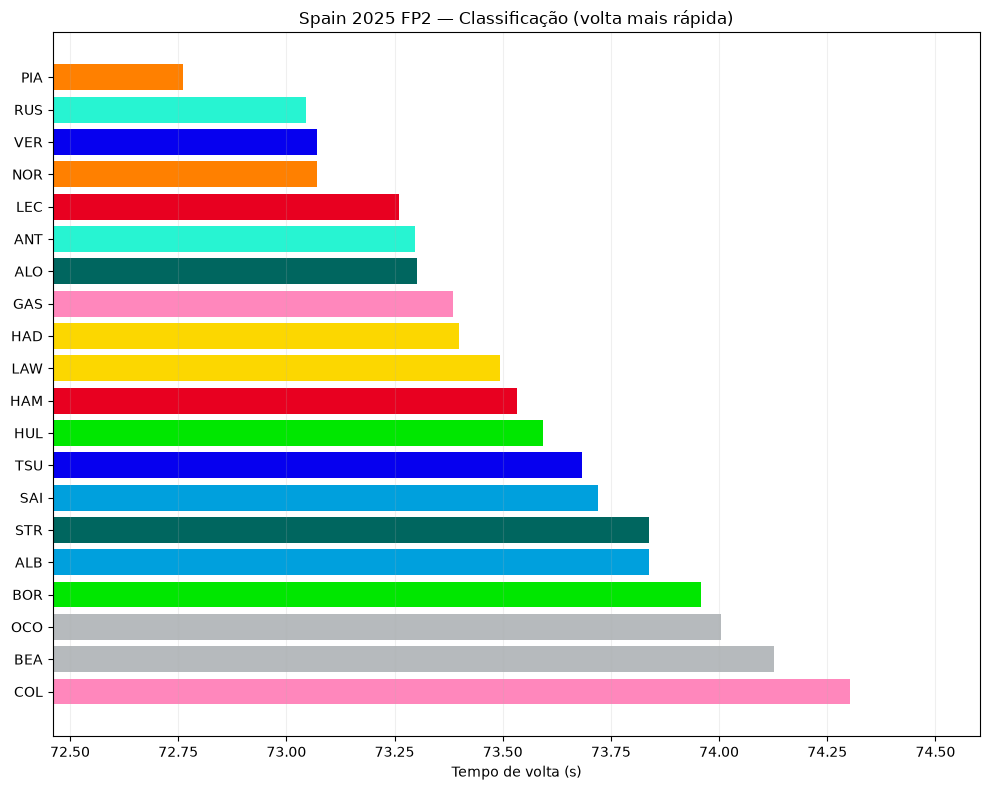

In [22]:
fig = ranking_sessao(2025, 'Spain', 'FP2')

# Testes com o GP da Austria 2026, primeiro GP pós criação do projeto

In [23]:
session_austria = fastf1.get_session(2026, 'Austria', 'Q')
session_austria.load()

print("Sessão da Áustria carregada!")

Sessão da Áustria carregada!


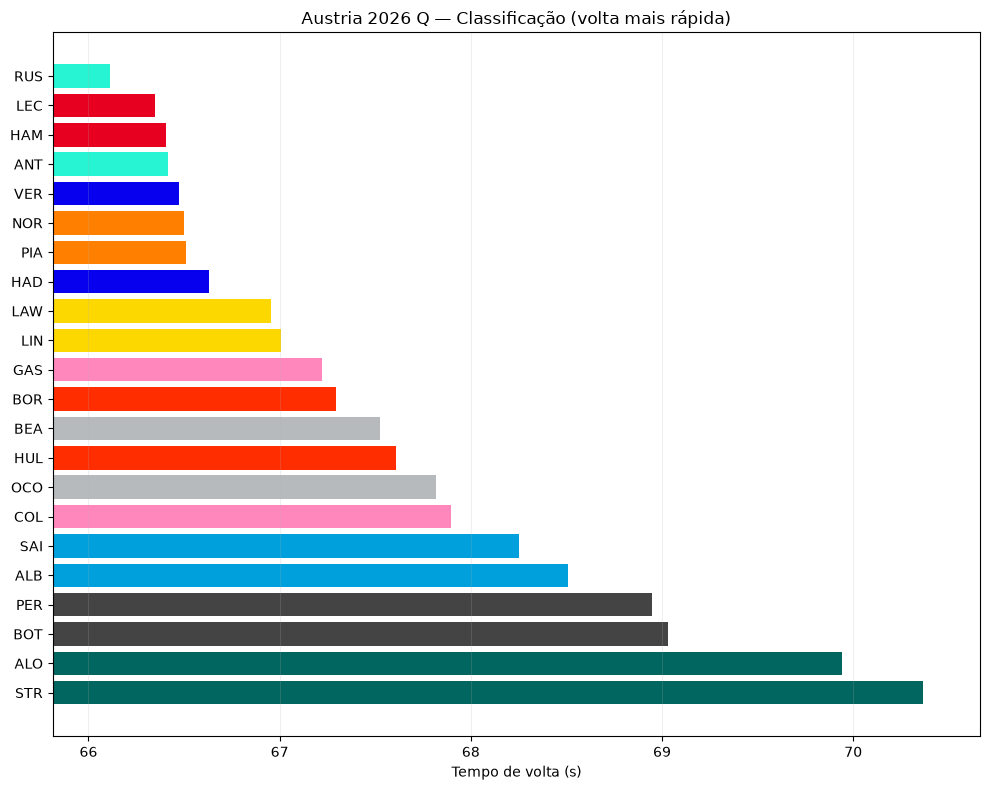

In [24]:
fig = ranking_sessao(2026, 'Austria', 'Q')
plt.show()  # ou fig  # no Jupyter mostra automaticamente

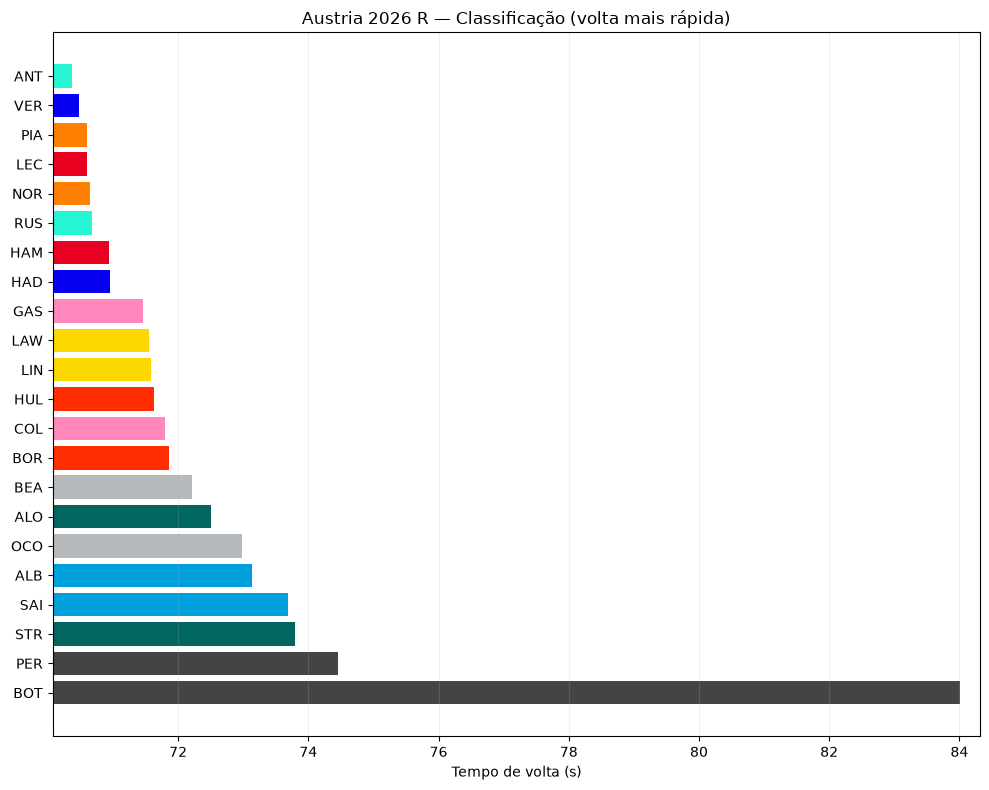

In [25]:
fig = ranking_sessao(2026, 'Austria', 'R')

# Compara setores da pista

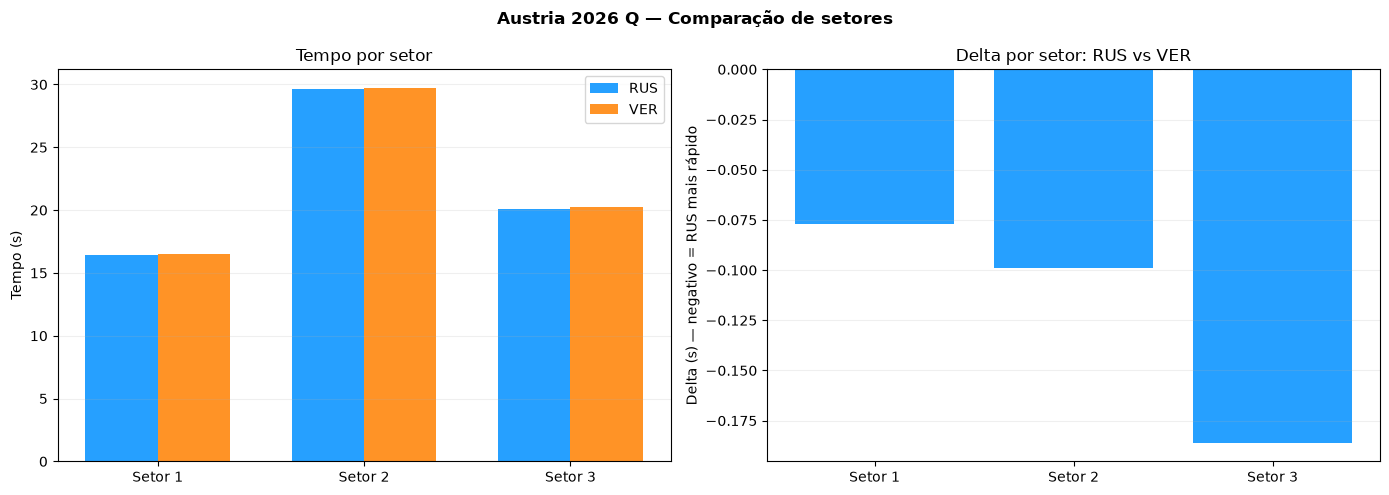

In [26]:
fig = comparar_setores(2026, 'Austria', 'Q', 'RUS', 'VER')